# LungCancerResCNN: A Custom Residual Convolutional Neural Network for Lung Cancer Classification

## Overview

`LungCancerResCNN` is a custom deep convolutional neural network inspired by the principles of the ResNet architecture. The model incorporates **residual (skip) connections**, **batch normalization**, **dropout regularization**, and **global average pooling** to improve gradient flow, accelerate convergence, and reduce overfitting.

The network is designed for **three-class lung cancer image classification** and outputs raw logits that are intended to be used with `CrossEntropyLoss`.

---

# Model Architecture

```text
Input Image (3 × H × W)
        │
        ▼
┌───────────────────────────────┐
│ Residual Block (3 → 8)        │
│ Conv3×3 → BN → ReLU           │
│ Conv3×3 → BN                  │
│ Shortcut: Conv1×1 + BN        │
└───────────────────────────────┘
        │
        ▼
MaxPool2D (2×2)

        ▼
┌───────────────────────────────┐
│ Residual Block (8 → 16)       │
│ Conv3×3 → BN → ReLU           │
│ Conv3×3 → BN                  │
│ Shortcut: Conv1×1 + BN        │
└───────────────────────────────┘
        │
        ▼
MaxPool2D (2×2)

        ▼
┌───────────────────────────────┐
│ Residual Block (16 → 32)      │
│ Conv3×3 → BN → ReLU           │
│ Conv3×3 → BN                  │
│ Shortcut: Conv1×1 + BN        │
└───────────────────────────────┘
        │
        ▼
MaxPool2D (2×2)

        ▼
┌───────────────────────────────┐
│ Residual Block (32 → 64)      │
│ Conv3×3 → BN → ReLU           │
│ Conv3×3 → BN                  │
│ Shortcut: Conv1×1 + BN        │
└───────────────────────────────┘
        │
        ▼
MaxPool2D (2×2)

        ▼
┌───────────────────────────────┐
│ Residual Block (64 → 128)     │
│ Conv3×3 → BN → ReLU           │
│ Conv3×3 → BN                  │
│ Shortcut: Conv1×1 + BN        │
└───────────────────────────────┘
        │
        ▼
MaxPool2D (2×2)

        ▼
Adaptive Average Pooling (1×1)

        ▼
Flatten (128 Features)

        ▼
Linear (128 → 256)
BatchNorm1D
ReLU
Dropout (0.2)

        ▼
Linear (256 → 128)
BatchNorm1D
ReLU
Dropout (0.2)

        ▼
Linear (128 → 3)

        ▼
Output Logits (3 Classes)

# Problem Statement

Lung cancer remains one of the leading causes of cancer-related mortality worldwide, making early and accurate diagnosis critical for improving patient outcomes. Manual analysis of histopathological images is time-consuming and requires significant expertise, motivating the development of automated computer-aided diagnostic systems.

This project focuses on building a deep learning-based image classification model capable of identifying and distinguishing between healthy lung tissue and major subtypes of lung cancer from histopathological images. The objective is to leverage convolutional neural networks and residual learning techniques to assist in accurate and efficient lung cancer detection.

---

# Dataset Overview

The dataset consists of histopathological lung tissue images categorized into three classes:

| Class Label | Description |
|-------------|-------------|
| `lung_n` | Normal lung tissue (non-cancerous) |
| `lung_aca` | Lung Adenocarcinoma |
| `lung_scc` | Lung Squamous Cell Carcinoma |

The classification task is formulated as a **three-class supervised image classification problem**, where the model learns to assign each input image to one of the following categories:

1. **Normal Lung Tissue (`lung_n`)**
2. **Lung Adenocarcinoma (`lung_aca`)**
3. **Lung Squamous Cell Carcinoma (`lung_scc`)**

The developed system aims to accurately classify these tissue types while maintaining robustness and generalization across unseen validation samples.

---

# Project Objective

The primary objective of this work is to design, train, and evaluate a residual convolutional neural network capable of learning discriminative visual features from lung histopathology images to support automated lung cancer diagnosis and subtype classification.

In [31]:
# Code Starts from here

In [32]:
# Installing dependencies and libraries
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from zipfile import ZipFile
import warnings
warnings.filterwarnings('ignore')

In [33]:
# Check if the GPU's are connected or not..
device = 'cuda' if torch.cuda.is_available else "cpu"
print(f'Currently connected on :- {device}')

Currently connected on :- cuda


**Dataset Info Here**

In [34]:

# I have upload the dataset in my drive but the original dataset can be retrived from this link
# https://drive.google.com/drive/folders/1vcw8JRQr8-62IVvix4rK4rDXrFnlap8e

In [35]:
# Unzip the dataset and load it to the device and into the model
from zipfile import ZipFile
data_path = '/content/drive/MyDrive/My Projects/Lung Cancer Detection Project/lung_subset_small-20260628T095419Z-3-001.zip'
with ZipFile(data_path, 'r') as zip:
    zip.extractall()
    print('The data set has been extracted.')

The data set has been extracted.


Image Size:- 128 Batch Size:- 16


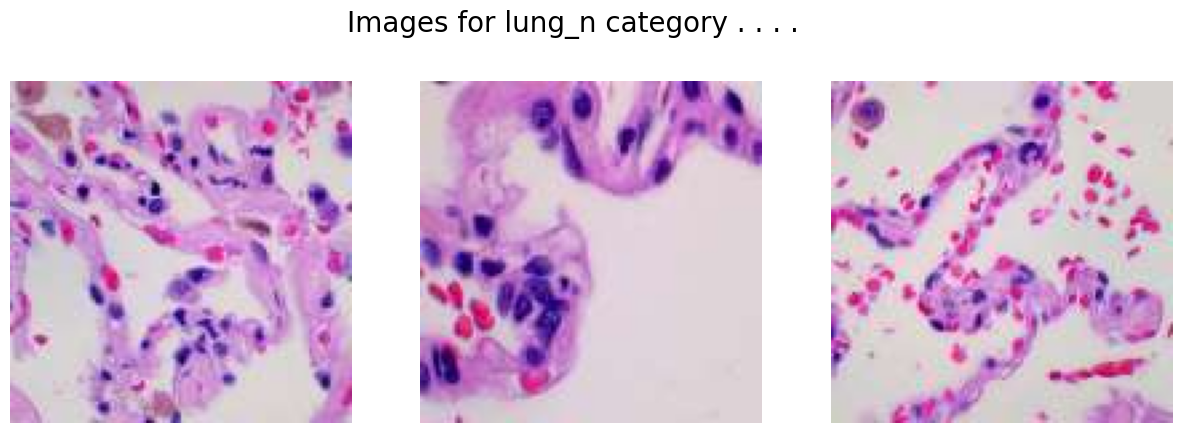

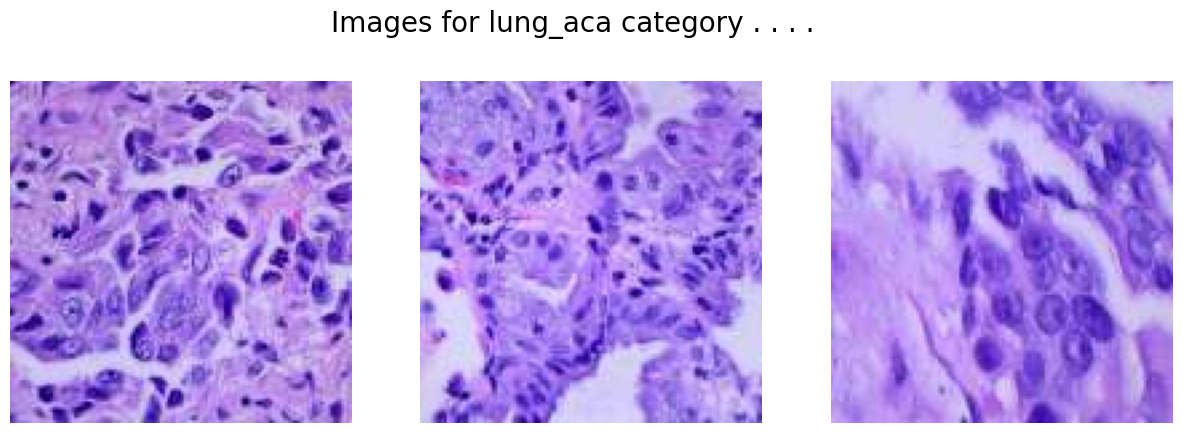

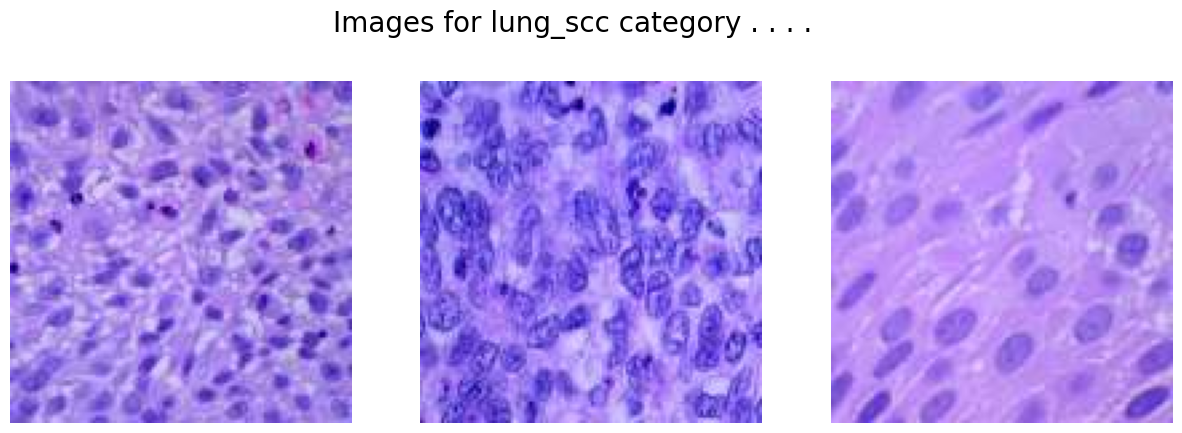

In [36]:
# Dataset Visualization
path = 'lung_subset_small'
IMG_SIZE = 128
BATCH_SIZE = 16


print(f'Image Size:- {IMG_SIZE}',f'Batch Size:- {BATCH_SIZE}')
classes = ['lung_n', 'lung_aca', 'lung_scc']

for c in classes:
    image_dir = f'{path}/{c}'
    images = os.listdir(image_dir)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Images for {c} category . . . .', fontsize=20)

    for i in range(3):
        k = np.random.randint(0, len(images))
        img = np.array(Image.open(f'{path}/{c}/{images[k]}'))
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()

In [37]:
# Define transformations for training and validation data
# This is similar to rescale=1./255 and validation_split in ImageDataGenerator
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), # Scales pixel values to [0, 1]
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), # Scales pixel values to [0, 1]
])

# Load the dataset using ImageFolder, which assumes structure: root/class_name/image.jpg
full_dataset = datasets.ImageFolder(root=path, transform=None) # Apply transforms later after splitting

# Calculate split sizes
total_size = len(full_dataset)
val_size = int(0.2 * total_size)
train_size = total_size - val_size

# Split the dataset
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_dataset_transformed = TransformedSubset(train_dataset, transform=train_transform)
val_dataset_transformed = TransformedSubset(val_dataset, transform=val_transform)


# Create DataLoaders
train_dataloader = DataLoader(train_dataset_transformed, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset_transformed, batch_size=BATCH_SIZE, shuffle=False)

print(f"Found {len(train_dataloader.dataset)} training images belonging to {len(train_dataloader.dataset.subset.dataset.classes)} classes.")
print(f"Found {len(val_dataloader.dataset)} validation images belonging to {len(val_dataloader.dataset.subset.dataset.classes)} classes.")

Found 1920 training images belonging to 3 classes.
Found 480 validation images belonging to 3 classes.


**Resdual Block Here**


In [38]:
# =====================================================
# Residual Block
# =====================================================
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)


        # Projection shortcut if dimensions change
        self.shortcut = nn.Sequential()

        if in_channels != out_channels:

            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )


        self.relu = nn.ReLU(inplace=True)


    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity

        out = self.relu(out)

        return out

**Model here with the implementation of Residual Block Connection**

In [39]:
class LungCancerResCNN(nn.Module):

    def __init__(self, img_size):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            ResidualBlock(3, 8),
            nn.MaxPool2d(2),

            # Block 2
            ResidualBlock(8, 16),
            nn.MaxPool2d(2),

            # Block 3
            ResidualBlock(16, 32),
            nn.MaxPool2d(2),

            # Block 4
            ResidualBlock(32, 64),
            nn.MaxPool2d(2),

            # Block 5
            ResidualBlock(64, 128),
            nn.MaxPool2d(2),
        )

        # Global Average Pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier
        self.classifier = nn.Sequential(

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),

            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),

            nn.Dropout(0.2),

            nn.Linear(128, 3)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [40]:
# Final Model Declarations
model = LungCancerResCNN(IMG_SIZE)
model = model.to(device)
print(model)

LungCancerResCNN(
  (features): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ResidualBlock(
      (conv1): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, k

In [41]:
# Training Configuration

EPOCHS = 20

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)



# LR Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)



# History Storage
train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []



# Best Model Tracking
best_test_loss = float('inf')
best_test_accuracy = 0.0
best_epoch = 0



# Training Loop
for epoch in range(EPOCHS):


    # TRAINING
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_dataloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)


    train_loss = running_train_loss / len(train_dataloader)
    train_accuracy = train_correct / train_total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    # TESTING
    model.eval()

    running_test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for images, labels in val_dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

            preds = outputs.argmax(dim=1)

            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)


    test_loss = running_test_loss / len(val_dataloader)
    test_accuracy = test_correct / test_total

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)



    # SAVE BEST MODEL (LOWEST TEST LOSS)
    if test_loss < best_test_loss:

        best_test_loss = test_loss
        best_test_accuracy = test_accuracy
        best_epoch = epoch + 1

        checkpoint = {
            "epoch": best_epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "test_loss": best_test_loss,
            "test_accuracy": best_test_accuracy,
        }

        torch.save(
            checkpoint,
            "best_lung_rescnn_checkpoint.pth"
        )

        print(
            f"\n Best model saved!"
            f"\n   Epoch          : {best_epoch}"
            f"\n   Test Loss      : {best_test_loss:.4f}"
            f"\n   Test Accuracy  : {best_test_accuracy * 100:.2f}%\n"
        )



    # UPDATE LR SCHEDULER
    scheduler.step(test_loss)



    # PRINT EPOCH METRIC
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch + 1:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy * 100:.2f}% | "
        f"LR: {current_lr:.7f}"
    )



# TRAINING SUMMARY
print("\n" + "=" * 60)
print("TRAINING COMPLETE")


print(f"Best Epoch            : {best_epoch}")
print(f"Best Test Loss        : {best_test_loss:.4f}")
print(f"Best Test Accuracy    : {best_test_accuracy * 100:.2f}%")
print("Saved Checkpoint      : best_lung_rescnn_checkpoint.pth")


 Best model saved!
   Epoch          : 1
   Test Loss      : 0.3309
   Test Accuracy  : 88.54%

Epoch [01/20] | Train Loss: 0.5110 | Train Acc: 81.46% | Test Loss: 0.3309 | Test Acc: 88.54% | LR: 0.0001000

 Best model saved!
   Epoch          : 2
   Test Loss      : 0.2656
   Test Accuracy  : 90.42%

Epoch [02/20] | Train Loss: 0.3286 | Train Acc: 89.22% | Test Loss: 0.2656 | Test Acc: 90.42% | LR: 0.0001000

 Best model saved!
   Epoch          : 3
   Test Loss      : 0.2470
   Test Accuracy  : 91.88%

Epoch [03/20] | Train Loss: 0.2912 | Train Acc: 90.68% | Test Loss: 0.2470 | Test Acc: 91.88% | LR: 0.0001000
Epoch [04/20] | Train Loss: 0.2174 | Train Acc: 93.12% | Test Loss: 0.3479 | Test Acc: 86.46% | LR: 0.0001000

 Best model saved!
   Epoch          : 5
   Test Loss      : 0.2155
   Test Accuracy  : 92.92%

Epoch [05/20] | Train Loss: 0.1907 | Train Acc: 93.49% | Test Loss: 0.2155 | Test Acc: 92.92% | LR: 0.0001000

 Best model saved!
   Epoch          : 6
   Test Loss      : 

In [42]:
# Put model in evaluation mode
model.eval()

Y_pred_labels = []
Y_true = []

with torch.no_grad():

    for images, labels in val_dataloader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Predicted class indices
        preds = torch.argmax(outputs, dim=1)

        # Store predictions and ground truths
        Y_pred_labels.extend(preds.cpu().numpy())
        Y_true.extend(labels.cpu().numpy())


# Convert to NumPy arrays (optional)
Y_pred_labels = np.array(Y_pred_labels)
Y_true = np.array(Y_true)


# Print classification report
print(
    metrics.classification_report(
        Y_true,
        Y_pred_labels,
        target_names=classes
    )
)

              precision    recall  f1-score   support

      lung_n       0.93      0.93      0.93       164
    lung_aca       1.00      1.00      1.00       167
    lung_scc       0.93      0.93      0.93       149

    accuracy                           0.95       480
   macro avg       0.95      0.95      0.95       480
weighted avg       0.95      0.95      0.95       480



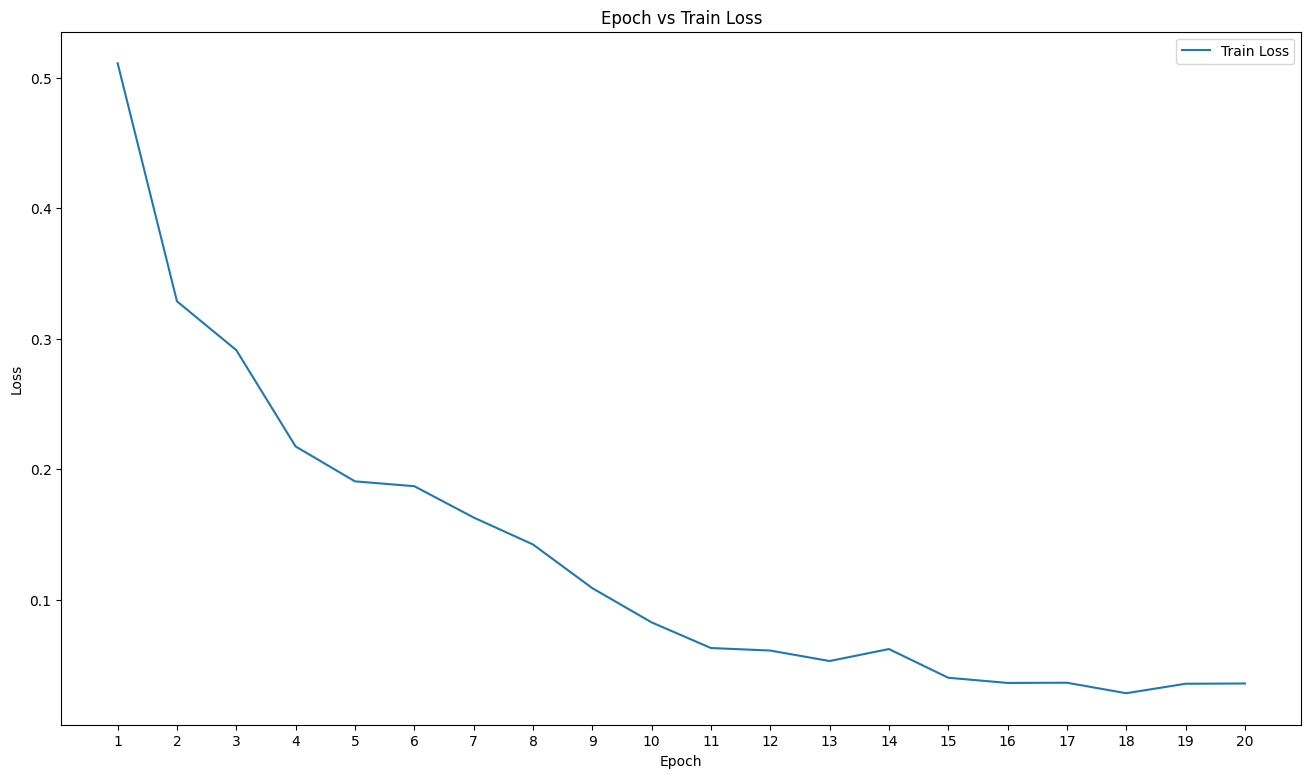

In [43]:
# PLOT 1: EPOCH VS TRAIN LOSS
plt.figure(figsize=(16, 9))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    label="Train Loss"
)
plt.xticks(range(1, EPOCHS + 1))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Train Loss")
plt.legend()

plt.show()

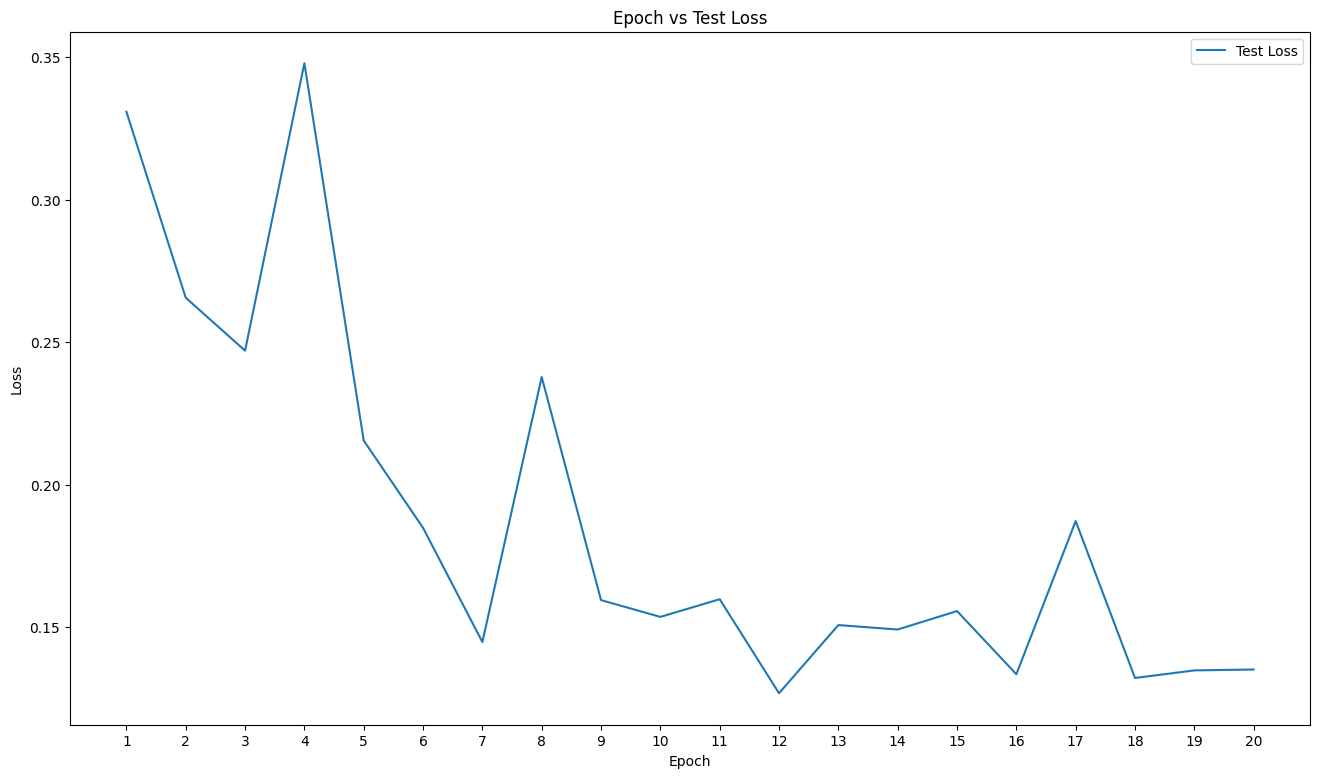

In [44]:
# PLOT 2: EPOCH VS TEST LOSS
plt.figure(figsize=(16, 9))

plt.plot(
    range(1, EPOCHS + 1),
    test_losses,
    label="Test Loss"
)
plt.xticks(range(1, EPOCHS + 1))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Test Loss")
plt.legend()
plt.show()

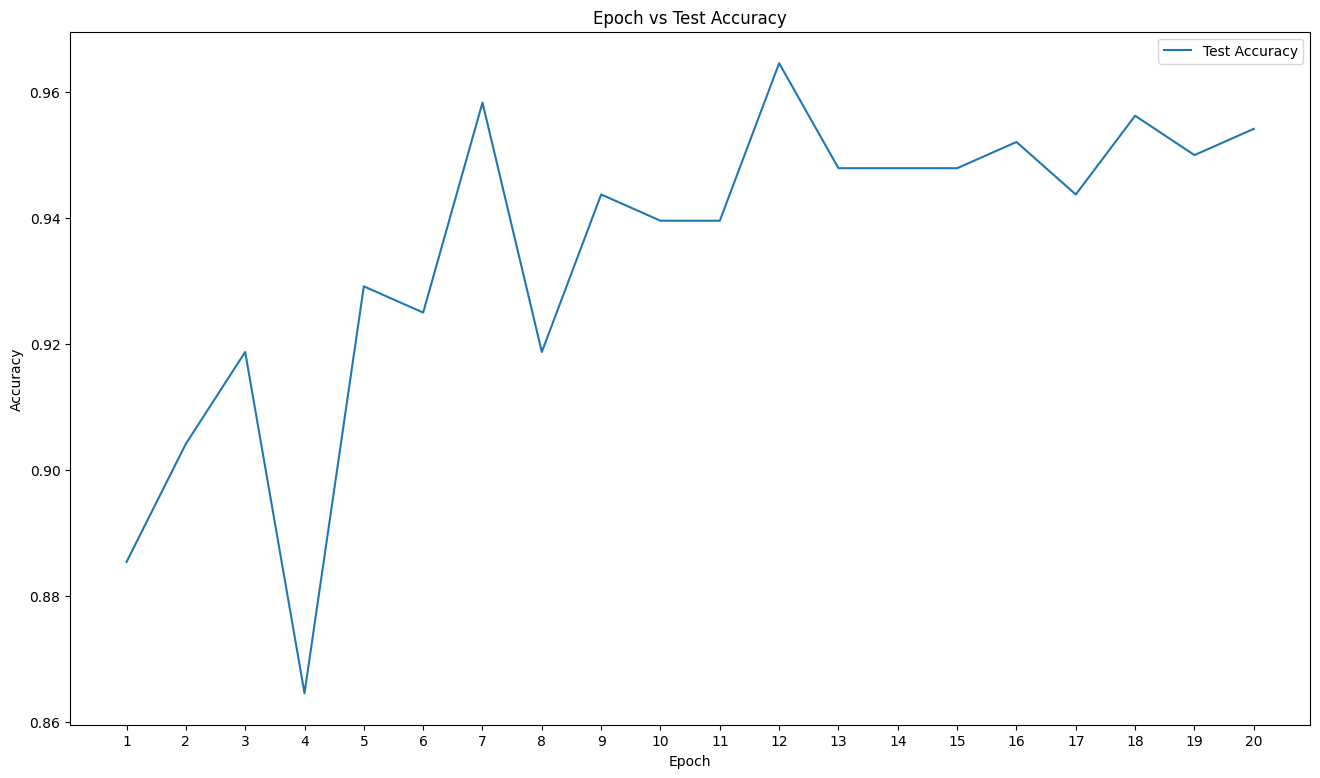

In [45]:
# PLOT 3: EPOCH VS TEST ACCURACY
plt.figure(figsize=(16, 9))

plt.plot(
    range(1, EPOCHS + 1),
    test_accuracies,
    label="Test Accuracy"
)
plt.xticks(range(1, EPOCHS + 1))
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Epoch vs Test Accuracy")
plt.legend()

plt.show()

In [46]:
# Print Performance Metrics

print("Performance Metrics".center(50))
print('-' * 50)
print(f'The Max accuracy model acheived :- {max(test_accuracies) * 100:.2f}%')
print(f'The best loss acheived by the model :- {min(test_losses):.4f} ')
print(f'The best train loss of the model:- {min(train_losses):.4f}')

               Performance Metrics                
--------------------------------------------------
The Max accuracy model acheived :- 96.46%
The best loss acheived by the model :- 0.1268 
The best train loss of the model:- 0.0285


In [47]:
# FINAL PREDICTIONS
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in val_dataloader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

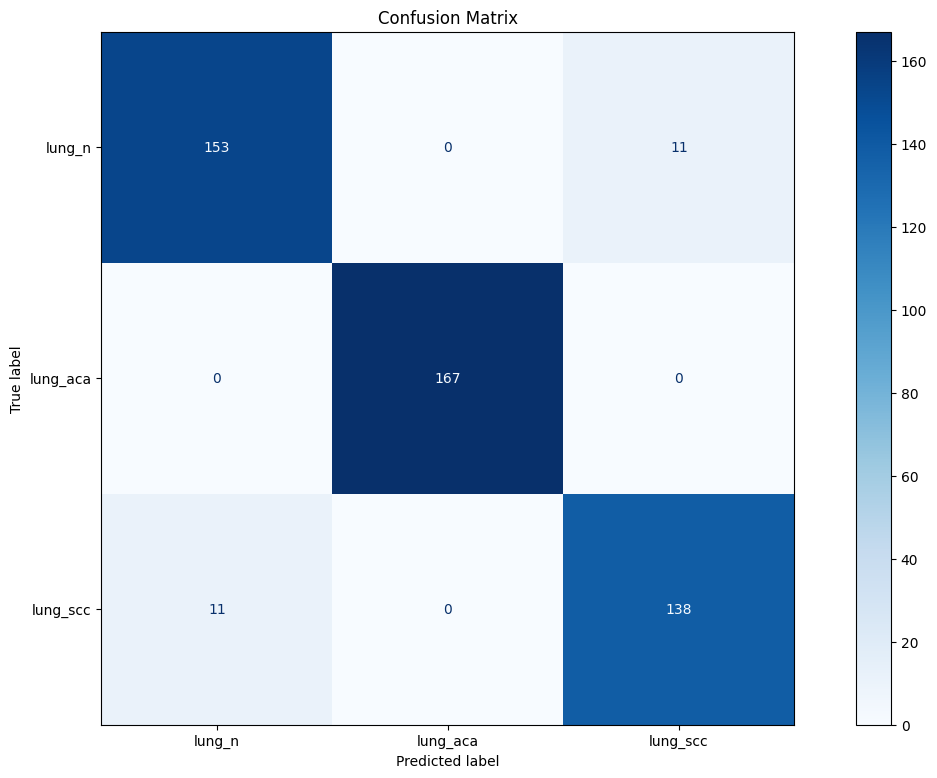

In [48]:
# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(16, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    ax=ax,

)

plt.title("Confusion Matrix")
plt.show()